# 1. Load Libraries

In [1]:
import pandas as pd
import os
from io import BytesIO
from pathlib import Path
from dotenv import load_dotenv
from elevenlabs.client import ElevenLabs

# 2. Load API Key
This code block needs to be separated so we can just restart the API key if ever we run out of credits. Once it did, change your key in the ```.env``` file. The ```override=True``` parameter in ```load_dotenv``` will make sure it will not use the previous key.

In [15]:
load_dotenv(override=True)
model = ElevenLabs(api_key=os.getenv("ELEVENLABS_API_KEY"))

# 3. Data Exploration and Variable Initialization

In [3]:
parquet_files = sorted(Path("data/bisaya_audio").glob("*.parquet"))

for file in parquet_files:
    df_temp = pd.read_parquet(file)
    print(f"{file.name}: {len(df_temp):,} rows")

test-00000-of-00011.parquet: 7 rows
test-00001-of-00011.parquet: 11 rows
test-00002-of-00011.parquet: 9 rows
test-00003-of-00011.parquet: 4 rows
test-00004-of-00011.parquet: 6 rows
test-00005-of-00011.parquet: 5 rows
test-00006-of-00011.parquet: 7 rows
test-00007-of-00011.parquet: 14 rows
test-00008-of-00011.parquet: 18 rows
test-00009-of-00011.parquet: 5 rows
test-00010-of-00011.parquet: 4 rows


In [4]:
dfs = []

for file in parquet_files:
    temp = pd.read_parquet(file)
    parquet_num = int(file.stem.split("-")[1])
    temp["row"] = range(1, len(temp) + 1)
    temp["id"] = temp["row"].apply(
        lambda x: f"{parquet_num:03d}_{x:03d}"
    )

    temp["parquet_file"] = file.name

    dfs.append(temp)

data_df = pd.concat(dfs, ignore_index=True)

In [51]:
print(data_df["duration"].sum())

12527.069999999998


In [5]:
print(data_df.head())

                                               audio speaker_id language  \
0  {'bytes': b'RIFF\xa4\x93\x90\x01WAVEfmt \x10\x...    CEB_008  Cebuano   
1  {'bytes': b'RIFF$\xe3\x0c\x01WAVEfmt \x10\x00\...    CEB_008  Cebuano   
2  {'bytes': b'RIFF\xa4\xcb\x0c\x02WAVEfmt \x10\x...    CEB_008  Cebuano   
3  {'bytes': b'RIFF\xa4\x9bY\x03WAVEfmt \x10\x00\...    CEB_008  Cebuano   
4  {'bytes': b'RIFF$\xea\xaa\x01WAVEfmt \x10\x00\...    CEB_008  Cebuano   

                                          transcript  transcript_type gender  \
0  Niadto ako og picnic niadto miaging bulan sa u...  human_validated   male   
1  Ang pulong dululanan kasagarang gigamit sa Pil...  human_validated   male   
2  Kanus-a ang imong adlaw natawhan? Usa kini sa ...  human_validated   male   
3  Sa modernong panahon, halos tanan nato napugos...  human_validated   male   
4  Sa atong adlaw-adlaw nga kinabuhi, ang kwarta ...  human_validated   male   

       country       mother_tongue                         dia

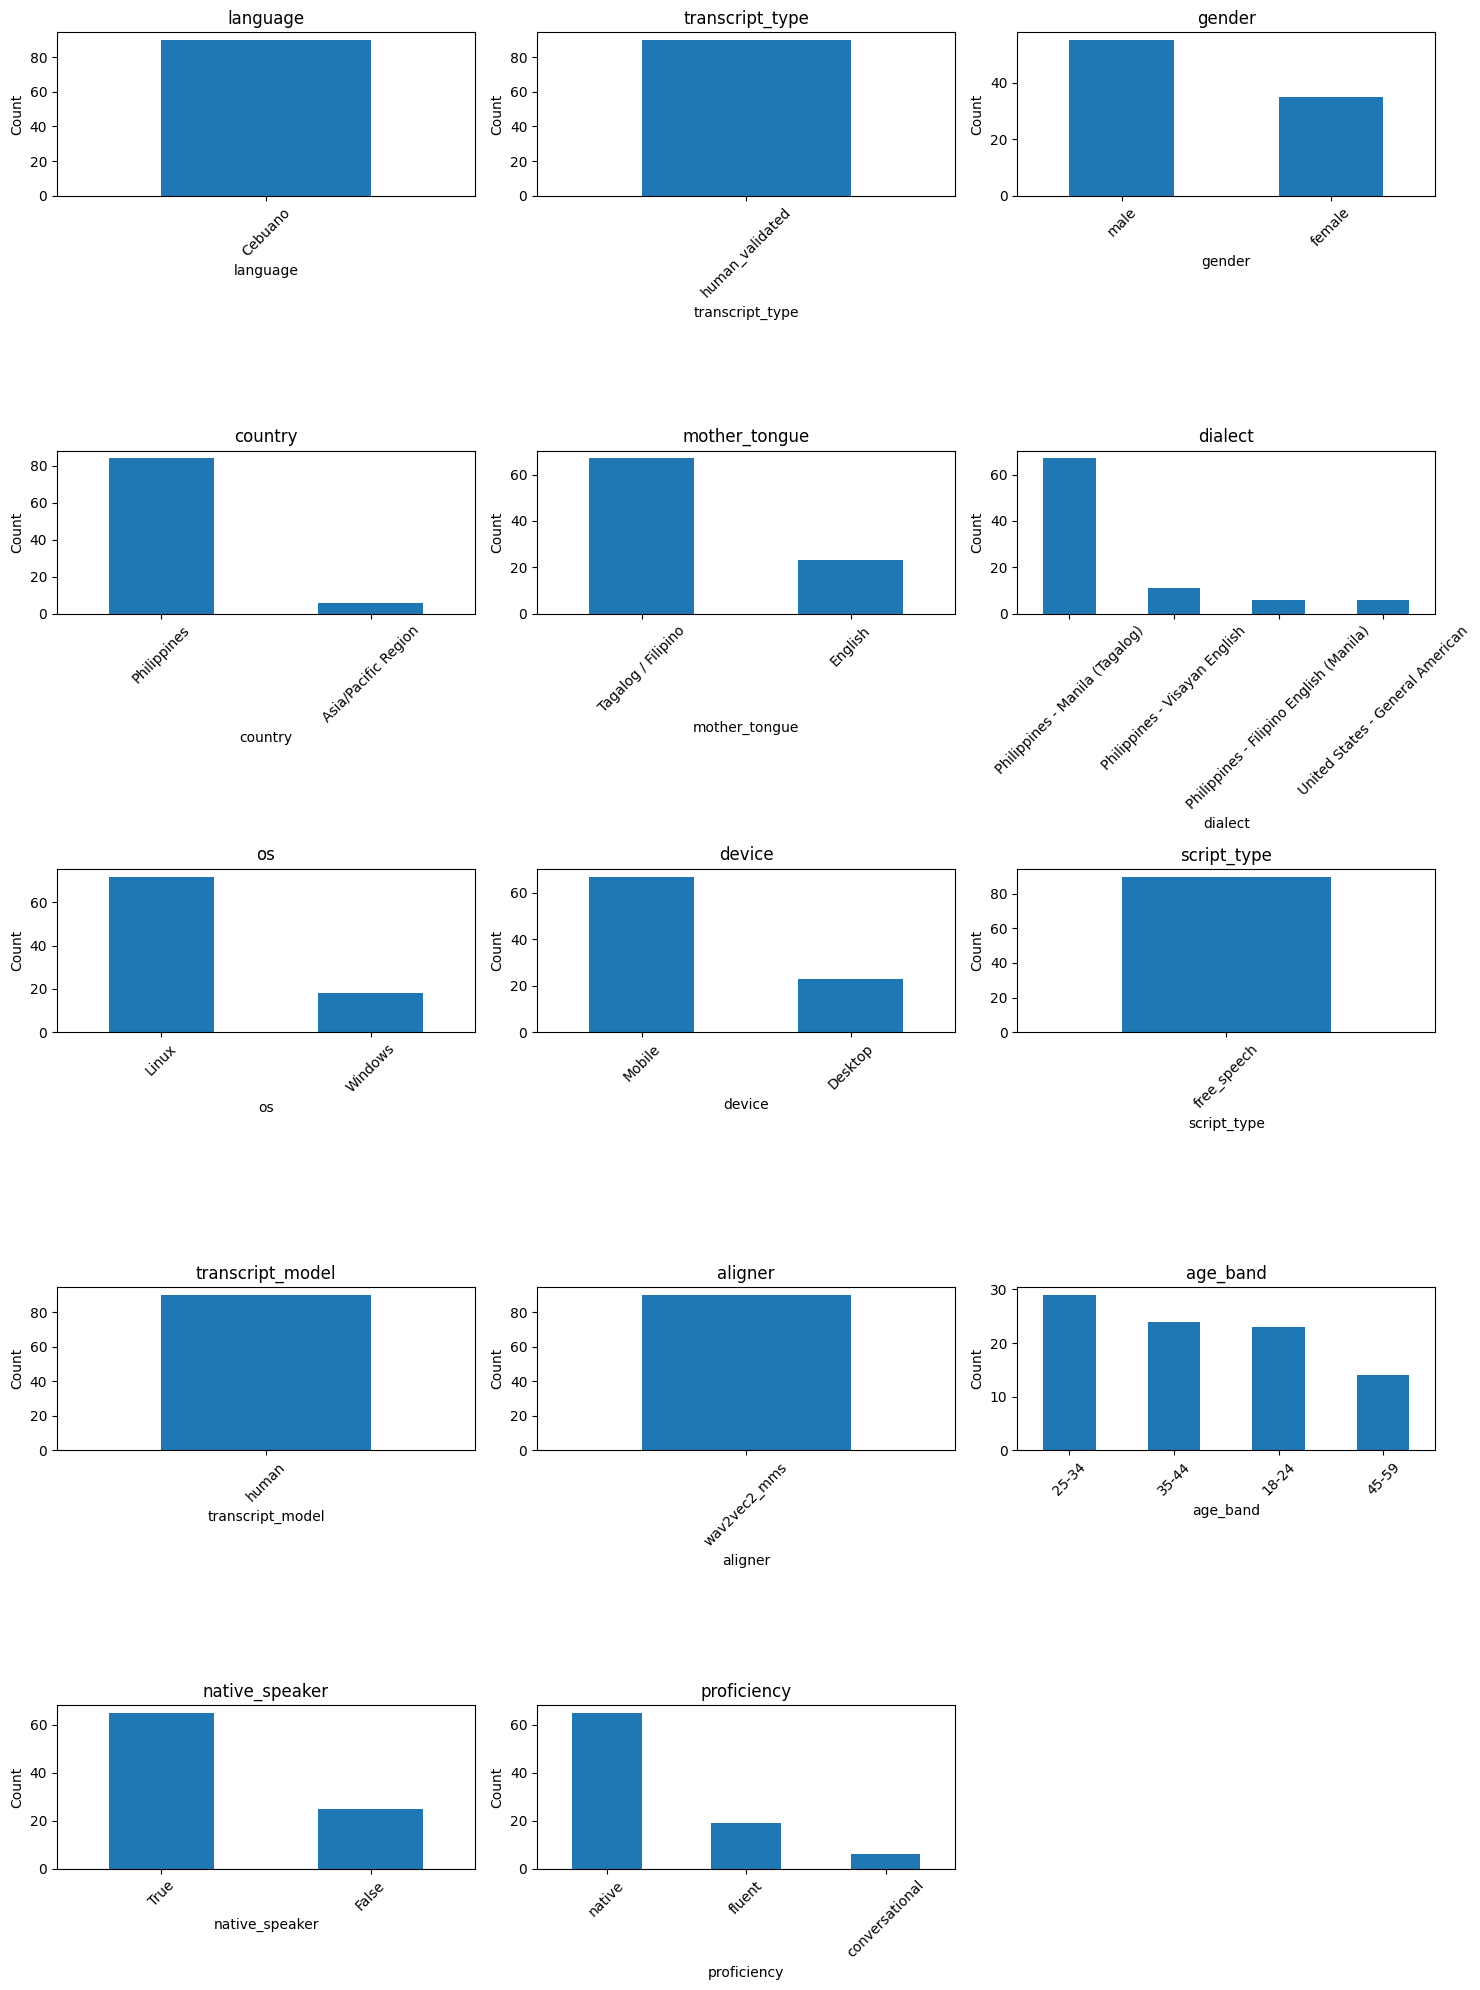

In [22]:
import matplotlib.pyplot as plt

exclude = [
    "audio", "speaker_id", "transcript", "duration",
    "words", "n_words", "row", "id", "parquet_file"
]

cols = [col for col in data_df.columns if col not in exclude]

fig, axes = plt.subplots(
    nrows=(len(cols) + 2) // 3,
    ncols=3,
    figsize=(15, 4 * ((len(cols) + 2) // 3))
)

axes = axes.flatten()

for ax, col in zip(axes, cols):
    counts = data_df[col].value_counts(dropna=False)

    counts.plot(kind="bar", ax=ax)

    ax.set_title(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

# Hide unused plots
for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

This is to resume the iteration if ever it fails due to credit depletion

In [7]:
CHECKPOINT_PATH = "scribe_raw_results.parquet"

if Path(CHECKPOINT_PATH).exists():
    checkpoint_df = pd.read_parquet(CHECKPOINT_PATH)

    if "id" not in checkpoint_df.columns:
        checkpoint_df["id"] = checkpoint_df.apply(
            lambda r: f"{int(r['parquet_file'].split('-')[1]):03d}_{int(r['row']):03d}",
            axis=1
        )
else:
    checkpoint_df = pd.DataFrame(
        columns=["id", "parquet_file", "row", "speaker_id", "reference", "prediction"]
    )

completed_ids = set(checkpoint_df["id"])
checkpoint_records = checkpoint_df.to_dict("records")

def save_checkpoint(records):
    tmp_path = CHECKPOINT_PATH + ".tmp"
    pd.DataFrame(records).to_parquet(tmp_path, index=False)
    os.replace(tmp_path, CHECKPOINT_PATH)

print(f"Checkpoint loaded: {len(completed_ids)} samples already transcribed.")
print(f"Remaining to process: {len(data_df) - len(completed_ids)} / {len(data_df)}")

Checkpoint loaded: 41 samples already transcribed.
Remaining to process: 49 / 90


# 4. Model Iteration to Audio Files
This iterates over every audio sample in `data_df` and transcribes it. Resume is now automatic:
any `id` already present in the checkpoint file (`scribe_raw_results.parquet`, loaded in the
previous cell) is skipped, so you never need to manually track which parquet file or row you
stopped at.

Every successful transcription is appended to `checkpoint_records` and the checkpoint file is
immediately overwritten (atomically, via `save_checkpoint()`). If a call fails (out of ElevenLabs
credits, network error, etc.), the sample is **not** recorded and the loop stops — since further
calls will very likely fail the same way (e.g. zero credits). Fix the issue (see cell 3 for
swapping API keys) and just rerun this cell: already-completed samples are skipped automatically
and new results are appended, never overwritten.

In [16]:
for _, row in data_df.iterrows():

    sample_id = row["id"]

    # Already transcribed in a previous run (or earlier in this run) -- skip it.
    if sample_id in completed_ids:
        continue

    print(f"{row['parquet_file']} — id {sample_id}")

    audio_bytes = row["audio"]["bytes"]
    audio_file = BytesIO(audio_bytes)

    try:
        result = model.speech_to_text.convert(
            file=audio_file,
            model_id="scribe_v2",
            language_code="ceb"
        )
    except Exception as e:
        print(f"  FAILED on {sample_id}: {e}")
        print("  Stopping this run (further calls will likely fail the same way, e.g. "
              "zero credits). Fix the issue and rerun this cell -- it will resume "
              "automatically from here.")
        break

    checkpoint_records.append({
        "id": sample_id,
        "parquet_file": row["parquet_file"],
        "row": row["row"],
        "speaker_id": row["speaker_id"],
        "reference": row["transcript"],
        "prediction": result.text
    })
    completed_ids.add(sample_id)

    save_checkpoint(checkpoint_records)

print(f"\nDone this run. Total transcribed so far: {len(checkpoint_records)} / {len(data_df)}")

test-00004-of-00011.parquet — id 004_001
test-00004-of-00011.parquet — id 004_002
test-00004-of-00011.parquet — id 004_003
test-00004-of-00011.parquet — id 004_004
test-00004-of-00011.parquet — id 004_005
test-00004-of-00011.parquet — id 004_006
test-00005-of-00011.parquet — id 005_001
test-00005-of-00011.parquet — id 005_002
test-00005-of-00011.parquet — id 005_003
test-00005-of-00011.parquet — id 005_004
test-00005-of-00011.parquet — id 005_005
test-00006-of-00011.parquet — id 006_001
test-00006-of-00011.parquet — id 006_002
test-00006-of-00011.parquet — id 006_003
test-00006-of-00011.parquet — id 006_004
test-00006-of-00011.parquet — id 006_005
test-00006-of-00011.parquet — id 006_006
test-00006-of-00011.parquet — id 006_007

Done this run. Total transcribed so far: 90 / 90


Results are already checkpointed progressively by the loop above. Reload the full, up-to-date
set from the checkpoint file into `results_df` for the WER/CER analysis below (this works even
if you only ran the analysis cells without re-running the transcription loop in this session).

In [17]:
results_df = pd.read_parquet(CHECKPOINT_PATH)

print(results_df.count())

parquet_file    90
row             90
speaker_id      90
reference       90
prediction      90
id              90
dtype: int64


In [18]:
save_checkpoint(results_df.to_dict("records"))
print(f"Checkpoint confirmed at '{CHECKPOINT_PATH}' with {len(results_df)} rows.")

Checkpoint confirmed at 'scribe_raw_results.parquet' with 90 rows.


# 5. Word and Character Error Rate Calculation

Word Error Rate (WER) and Character Error Rate (CER) were used to evaluate the
speech-to-text transcription performance. Both metrics are based on the number
of substitutions (S), deletions (D), insertions (I), and correctly recognized
units or hits (H).

The metrics are calculated as:

$$
\mathrm{WER} = \frac{S + D + I}{H + S + D}
$$

$$
\mathrm{CER} = \frac{S + D + I}{H + S + D}
$$

where, for WER, the units are words, while for CER, the units are characters.

We will both calculate WER and CER for both normalized and non-normalized text.

In [11]:
from jiwer import process_words, process_characters

In [34]:
data_df["normalized_reference"] = data_df["words"].apply(
    lambda words: " ".join(w["normalized_text"] for w in words)
)

#print(data_df[["transcript", "normalized_reference"]].head())

In [35]:
data_df["normalized_reference"] = data_df["words"].apply(
    lambda words: " ".join(w["normalized_text"] for w in words)
)

comparison = data_df[
    data_df["transcript"] != data_df["normalized_reference"]
][["transcript", "normalized_reference"]]

print(f"Different: {len(comparison):,}")
print(f"Same: {len(data_df) - len(comparison):,}")

print(comparison.head(10).to_string(index=False))

Different: 0
Same: 90
Empty DataFrame
Columns: [transcript, normalized_reference]
Index: []


This indicates that normalization doesn't do anything actually. However, that is only applicable for the current dataset. For reproducibility, we shall leave the normalization logic in the code.

In [27]:
results_df = results_df.merge(
    data_df[["id", "normalized_reference"]],
    on="id",
    how="left"
)

In [29]:
results = []

for _, row in results_df.iterrows():

    reference = row["reference"]
    prediction = row["prediction"]

    normalized_reference = row["normalized_reference"]

    word_result = process_words(reference, prediction)
    char_result = process_characters(reference, prediction)

    normalized_word_result = process_words(
        normalized_reference,
        prediction
    )

    normalized_char_result = process_characters(
        normalized_reference,
        prediction
    )

    results.append({
        "id": row["id"],

        # Raw WER
        "WER": word_result.wer,
        "WER_sub": word_result.substitutions,
        "WER_del": word_result.deletions,
        "WER_ins": word_result.insertions,
        "WER_hits": word_result.hits,

        # Raw CER
        "CER": char_result.cer,
        "CER_sub": char_result.substitutions,
        "CER_del": char_result.deletions,
        "CER_ins": char_result.insertions,
        "CER_hits": char_result.hits,

        # Normalized WER
        "norm_WER": normalized_word_result.wer,
        "norm_WER_sub": normalized_word_result.substitutions,
        "norm_WER_del": normalized_word_result.deletions,
        "norm_WER_ins": normalized_word_result.insertions,
        "norm_WER_hits": normalized_word_result.hits,

        # Normalized CER
        "norm_CER": normalized_char_result.cer,
        "norm_CER_sub": normalized_char_result.substitutions,
        "norm_CER_del": normalized_char_result.deletions,
        "norm_CER_ins": normalized_char_result.insertions,
        "norm_CER_hits": normalized_char_result.hits,
    })

metrics_df = pd.DataFrame(results)

In [30]:
print(metrics_df.head())

        id       WER  WER_sub  WER_del  WER_ins  WER_hits       CER  CER_sub  \
0  007_001  0.078947       12        2        1       176  0.028829       13   
1  007_002  0.068441       12        3        3       248  0.025917        4   
2  007_003  0.031963        7        0        0       212  0.008842        6   
3  007_004  0.107011       22        4        3       245  0.043643       24   
4  007_005  0.040230        6        1        0       167  0.009018        3   

   CER_del  CER_ins  ...  norm_WER  norm_WER_sub  norm_WER_del  norm_WER_ins  \
0        9       10  ...  0.078947            12             2             1   
1       23       14  ...  0.068441            12             3             3   
2        2        3  ...  0.031963             7             0             0   
3       22       23  ...  0.107011            22             4             3   
4        6        0  ...  0.040230             6             1             0   

   norm_WER_hits  norm_CER  norm_CER_s

In [31]:
from jiwer import process_words

# -------------------
# RAW ALIGNMENT
# -------------------

word_result = process_words(reference, prediction)

print("\nRAW ERRORS:")

for alignment in word_result.alignments[0]:
    ref_start = alignment.ref_start_idx
    ref_end = alignment.ref_end_idx
    hyp_start = alignment.hyp_start_idx
    hyp_end = alignment.hyp_end_idx

    ref_words = word_result.references[0][ref_start:ref_end]
    hyp_words = word_result.hypotheses[0][hyp_start:hyp_end]

    if alignment.type == "substitute":
        print(f"SUB: {ref_words} → {hyp_words}")

    elif alignment.type == "delete":
        print(f"DEL: {ref_words}")

    elif alignment.type == "insert":
        print(f"INS: {hyp_words}")


# -------------------
# NORMALIZED ALIGNMENT
# -------------------

normalized_word_result = process_words(
    normalized_reference,
    prediction
)

print("\nNORMALIZED ERRORS:")

for alignment in normalized_word_result.alignments[0]:
    ref_start = alignment.ref_start_idx
    ref_end = alignment.ref_end_idx
    hyp_start = alignment.hyp_start_idx
    hyp_end = alignment.hyp_end_idx

    ref_words = normalized_word_result.references[0][ref_start:ref_end]
    hyp_words = normalized_word_result.hypotheses[0][hyp_start:hyp_end]

    if alignment.type == "substitute":
        print(f"SUB: {ref_words} → {hyp_words}")

    elif alignment.type == "delete":
        print(f"DEL: {ref_words}")

    elif alignment.type == "insert":
        print(f"INS: {hyp_words}")


RAW ERRORS:
SUB: ['naku.'] → ['nako.']
SUB: ['pinakatumong'] → ['pinakatumaon']
SUB: ['og'] → ['ug']
SUB: ['stable'] → ['stables']
DEL: ['sa']
SUB: ['labi'] → ['ilabin']
SUB: ['kayo', 'mi'] → ['kaayo', 'may']
SUB: ['og', 'career.'] → ['ug', 'karer.']
SUB: ['og'] → ['o']
SUB: ['ang'] → ['sa']
SUB: ['ko', 'gi-nahimo'] → ["ko'y", 'ginahimo']
SUB: ['og'] → ['ug']
SUB: ['paghandle'] → ['paghandur']
SUB: ['problema,', 'og'] → ['problema', 'ug']
SUB: ['og'] → ['ug']
SUB: ['samok,'] → ['samok']
INS: ['nga']
SUB: ['nangan-an'] → ['naa']
SUB: ['maningkamot'] → ['paningkamot']
DEL: ['kong']

NORMALIZED ERRORS:
SUB: ['naku.'] → ['nako.']
SUB: ['pinakatumong'] → ['pinakatumaon']
SUB: ['og'] → ['ug']
SUB: ['stable'] → ['stables']
DEL: ['sa']
SUB: ['labi'] → ['ilabin']
SUB: ['kayo', 'mi'] → ['kaayo', 'may']
SUB: ['og', 'career.'] → ['ug', 'karer.']
SUB: ['og'] → ['o']
SUB: ['ang'] → ['sa']
SUB: ['ko', 'gi-nahimo'] → ["ko'y", 'ginahimo']
SUB: ['og'] → ['ug']
SUB: ['paghandle'] → ['paghandur']
SUB: ['

As you can see, normalization does not change anything.

# 6. Analysis Set-up
For our analysis, we don't want to put every columns to the final dataframe. We will only consider ```'speaker_id', 'language', 'gender', 'country', 'mother_tongue', 'dialect', 'os', 'device', 'n_words', 'age_band', 'native_speaker', 'proficiency'``` as well as  WER/CER.

In [40]:
analysis_df = data_df[['speaker_id', 'language', 'gender', 'country', 'mother_tongue', 'dialect', 'os', 'device', 'n_words', 'age_band', 'native_speaker', 'proficiency',"id"]]

analysis_df = analysis_df.merge(
    metrics_df[[
        "id",
        "WER",
        "WER_sub",
        "WER_del",
        "WER_ins",
        "WER_hits",
        "CER",
        "CER_sub",
        "CER_del",
        "CER_ins",
        "CER_hits"]],
    on="id",
    how="left"
)

In [41]:
print(analysis_df.head())

  speaker_id language gender      country       mother_tongue  \
0    CEB_008  Cebuano   male  Philippines  Tagalog / Filipino   
1    CEB_008  Cebuano   male  Philippines  Tagalog / Filipino   
2    CEB_008  Cebuano   male  Philippines  Tagalog / Filipino   
3    CEB_008  Cebuano   male  Philippines  Tagalog / Filipino   
4    CEB_008  Cebuano   male  Philippines  Tagalog / Filipino   

                          dialect     os  device  n_words age_band  ...  \
0  Philippines - Manila (Tagalog)  Linux  Mobile      219    45-59  ...   
1  Philippines - Manila (Tagalog)  Linux  Mobile      138    45-59  ...   
2  Philippines - Manila (Tagalog)  Linux  Mobile      260    45-59  ...   
3  Philippines - Manila (Tagalog)  Linux  Mobile      475    45-59  ...   
4  Philippines - Manila (Tagalog)  Linux  Mobile      216    45-59  ...   

        WER WER_sub WER_del  WER_ins  WER_hits       CER  CER_sub  CER_del  \
0  0.041096       8       1        0       210  0.009569        5        3   
1 

In [42]:
print(analysis_df.columns)

Index(['speaker_id', 'language', 'gender', 'country', 'mother_tongue',
       'dialect', 'os', 'device', 'n_words', 'age_band', 'native_speaker',
       'proficiency', 'id', 'WER', 'WER_sub', 'WER_del', 'WER_ins', 'WER_hits',
       'CER', 'CER_sub', 'CER_del', 'CER_ins', 'CER_hits'],
      dtype='str')


# 7. Analysis

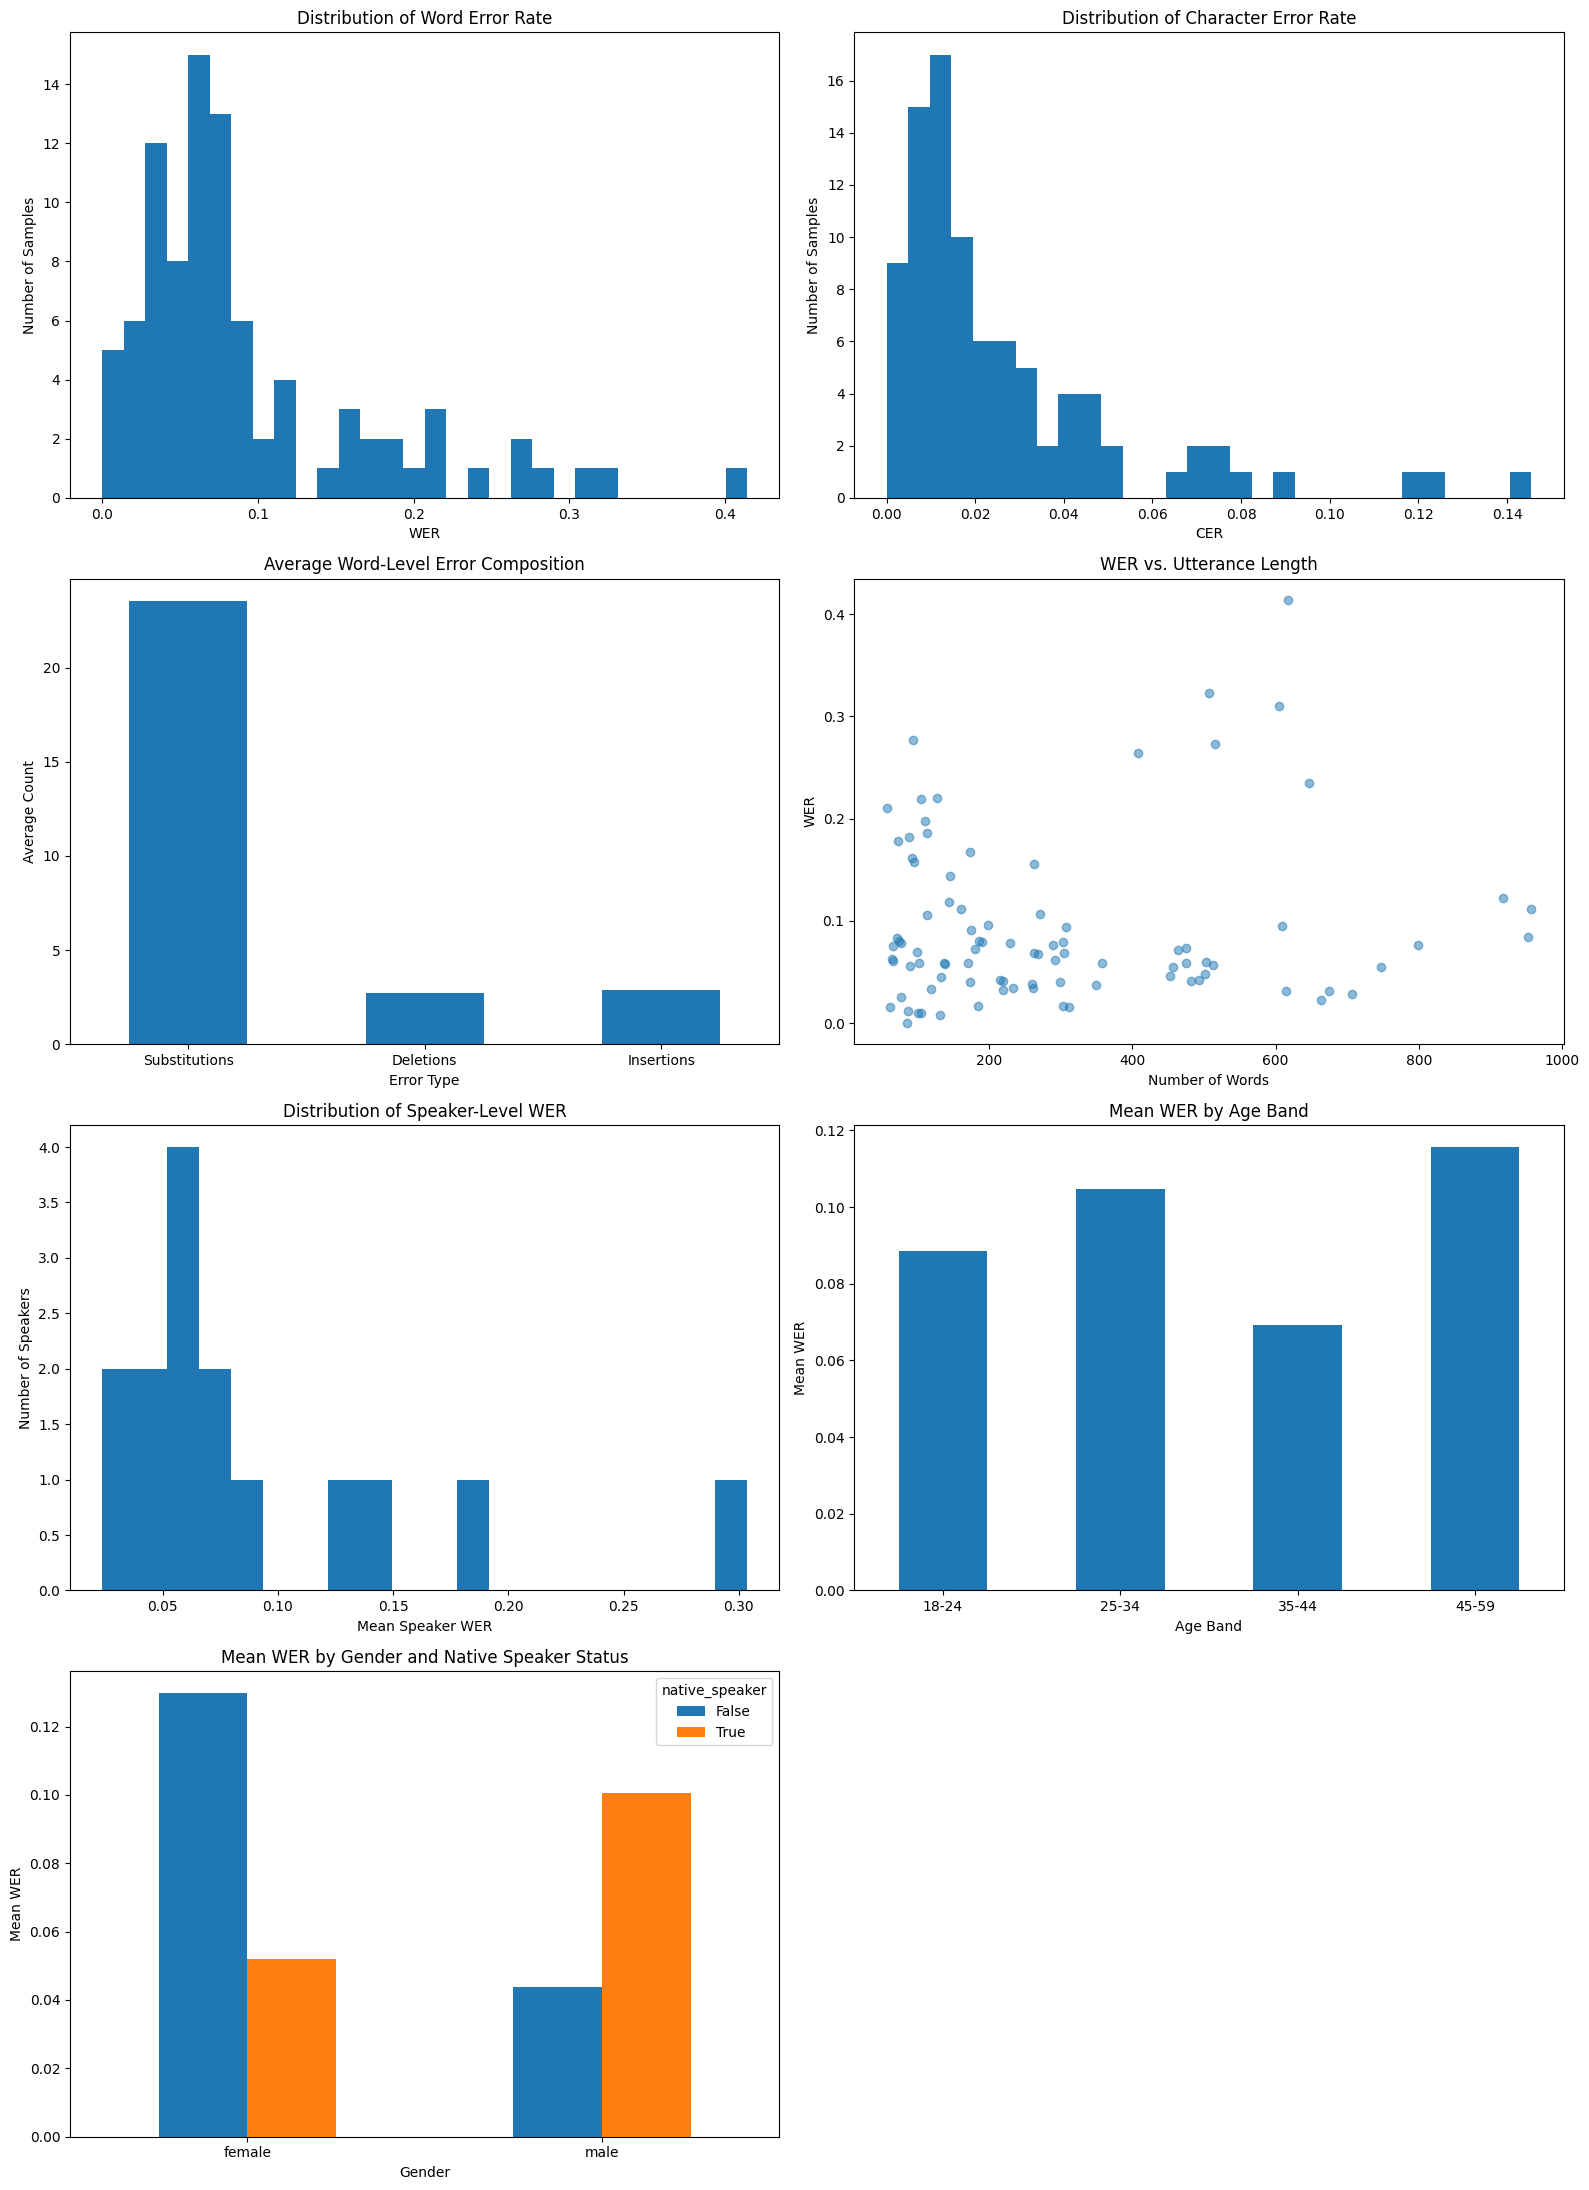

In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 2, figsize=(16, 22))

# --------------------------------------------------
# 1. WER distribution
# --------------------------------------------------
axes[0, 0].hist(analysis_df["WER"], bins=30)

axes[0, 0].set_xlabel("WER")
axes[0, 0].set_ylabel("Number of Samples")
axes[0, 0].set_title("Distribution of Word Error Rate")


# --------------------------------------------------
# 2. CER distribution
# --------------------------------------------------
axes[0, 1].hist(analysis_df["CER"], bins=30)

axes[0, 1].set_xlabel("CER")
axes[0, 1].set_ylabel("Number of Samples")
axes[0, 1].set_title("Distribution of Character Error Rate")


# --------------------------------------------------
# 3. Error composition
# --------------------------------------------------
error_means = analysis_df[
    ["WER_sub", "WER_del", "WER_ins"]
].mean()

error_means.plot(kind="bar", ax=axes[1, 0])

axes[1, 0].set_xlabel("Error Type")
axes[1, 0].set_ylabel("Average Count")
axes[1, 0].set_title("Average Word-Level Error Composition")
axes[1, 0].set_xticklabels(
    ["Substitutions", "Deletions", "Insertions"],
    rotation=0
)


# --------------------------------------------------
# 4. WER vs. utterance length
# --------------------------------------------------
axes[1, 1].scatter(
    analysis_df["n_words"],
    analysis_df["WER"],
    alpha=0.5
)

axes[1, 1].set_xlabel("Number of Words")
axes[1, 1].set_ylabel("WER")
axes[1, 1].set_title("WER vs. Utterance Length")


# --------------------------------------------------
# 5. Speaker-level WER distribution
# --------------------------------------------------
speaker_wer = (
    analysis_df
    .groupby("speaker_id")["WER"]
    .mean()
)

axes[2, 0].hist(speaker_wer, bins=20)

axes[2, 0].set_xlabel("Mean Speaker WER")
axes[2, 0].set_ylabel("Number of Speakers")
axes[2, 0].set_title("Distribution of Speaker-Level WER")


# --------------------------------------------------
# 6. WER by age
# --------------------------------------------------
age_wer = (
    analysis_df
    .groupby("age_band")["WER"]
    .mean()
    .sort_index()
)

age_wer.plot(kind="bar", ax=axes[2, 1])

axes[2, 1].set_xlabel("Age Band")
axes[2, 1].set_ylabel("Mean WER")
axes[2, 1].set_title("Mean WER by Age Band")
axes[2, 1].tick_params(axis="x", rotation=0)


# --------------------------------------------------
# 7. Gender × Native Speaker
# --------------------------------------------------
summary = (
    analysis_df
    .groupby(["gender", "native_speaker"])["WER"]
    .mean()
    .unstack()
)

summary.plot(kind="bar", ax=axes[3, 0])

axes[3, 0].set_xlabel("Gender")
axes[3, 0].set_ylabel("Mean WER")
axes[3, 0].set_title(
    "Mean WER by Gender and Native Speaker Status"
)
axes[3, 0].tick_params(axis="x", rotation=0)


# Hide the unused 8th subplot
axes[3, 1].set_visible(False)

plt.tight_layout()
plt.show()